<a href="https://colab.research.google.com/github/Durvankur-Rajam/Impactsure_Project/blob/main/Week5_Task1%2C2%2C4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spacy pymupdf -q
!python -m spacy download en_core_web_sm -q
print("All libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 49.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All libraries ready


In [ ]:
!wget -q "https://arxiv.org/pdf/2109.07958" -O truthfulqa.pdf
!wget -q "https://arxiv.org/pdf/2303.08896" -O selfcheckgpt.pdf
!wget -q "https://arxiv.org/pdf/1706.03762" -O attention.pdf

print("PDFs downloaded:")
!ls -lh *.pdf

PDFs downloaded:
-rw-r--r-- 1 root root 2.2M Apr 12  2024 attention.pdf
-rw-r--r-- 1 root root 882K Oct 12  2023 selfcheckgpt.pdf
-rw-r--r-- 1 root root 801K Jan 23  2023 truthfulqa.pdf


In [ ]:
import fitz
import re

def extract_and_clean(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    doc.close()
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

pdfs = {
    "TruthfulQA": "truthfulqa.pdf",
    "SelfCheckGPT": "selfcheckgpt.pdf",
    "Attention": "attention.pdf"
}

texts = {}
for name, path in pdfs.items():
    texts[name] = extract_and_clean(path)
    print(f"{name}: {len(texts[name])} characters loaded")

TruthfulQA: 92339 characters loaded
SelfCheckGPT: 53546 characters loaded
Attention: 39495 characters loaded


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text, nlp, max_chars=50000):
    doc = nlp(text[:max_chars])
    entities = {"PERSON": [], "ORG": [], "DATE": [], "GPE": [], "OTHER": []}

    for ent in doc.ents:
        if ent.label_ == "PERSON":
            entities["PERSON"].append(ent.text)
        elif ent.label_ == "ORG":
            entities["ORG"].append(ent.text)
        elif ent.label_ == "DATE":
            entities["DATE"].append(ent.text)
        elif ent.label_ == "GPE":
            entities["GPE"].append(ent.text)
        else:
            entities["OTHER"].append(f"{ent.text} ({ent.label_})")

    for key in entities:
        entities[key] = list(set(entities[key]))

    return entities

all_entities = {}
for name, text in texts.items():
    all_entities[name] = extract_entities(text, nlp)
    print(f"\n📄 {name}")
    print(f"   PERSON : {all_entities[name]['PERSON'][:5]}")
    print(f"   ORG    : {all_entities[name]['ORG'][:5]}")
    print(f"   DATE   : {all_entities[name]['DATE'][:5]}")


📄 TruthfulQA
   PERSON : ['Timnit Gebru', 'Daniel Toyama', 'Daniel M.\nZiegler', 'Geoffrey Irving', 'Julien\nChaumond']
   ORG    : ['Fairness, Accountability', 'Young, Eliza Rutherford', 'ML', 'Kalpesh Krishna', 'Tamkin']
   DATE   : ['1877–1901', '1611', '2004', '2021-09-06', 'May 2022']

📄 SelfCheckGPT
   PERSON : ['Shuailiang Zhang', 'NoFac NoFac', 'Lai et al.', 'Amanda Askell', 'Adina Williams']
   ORG    : ['Florence, Italy', 'MQAG', 'WikiBio', 'Kalpesh Krishna', '• Accurate']
   DATE   : ['13B', '1960', '1038', '1632', '2023']

📄 Attention
   PERSON : ['Vincent Vanhoucke', 'Peng Li', 'Slav Petrov', 'Krzysztof Maziarz', 'Luong Hoang']
   ORG    : ['Google Brain', 'Niki', 'ByteNet', 'Vinyals & Kaiser el al', 'Łukasz Kaiser∗']
   DATE   : ['2015', '1024', '1021', '2014', '+ 300']


In [ ]:
for name, entities in all_entities.items():
    print(f"\n{'='*50}")
    print(f"📄 PDF: {name}")
    print(f"{'='*50}")
    for label, items in entities.items():
        if items:
            print(f"\n  {label}:")
            for item in items[:10]:
                print(f"    • {item}")



📄 PDF: TruthfulQA

  PERSON:
    • Timnit Gebru
    • Daniel Toyama
    • Daniel M.
Ziegler
    • Geoffrey Irving
    • Julien
Chaumond
    • Adina Williams
    • Sam McCandlish
    • Peter Welinder
    • Kreps et al.
    • includ-
ing

  ORG:
    • Fairness, Accountability
    • Young, Eliza Rutherford
    • ML
    • Kalpesh Krishna
    • Tamkin
    • AI2
    • Tushar
Khot
    • Kareem Ayoub
    • Heewoo Jun,
    • Thibault Sottiaux

  DATE:
    • 1877–1901
    • 1611
    • 2004
    • 2021-09-06
    • May 2022
    • 2021-08-
    • 1241
    • 1906–1919
    • 2018
    • 2019

  GPE:
    • Barcelona
    • Subbiah
    • Esme Sutherland
    • Casas
    • Minneapolis
    • New York
    • Komatsuzaki
    • Louisiana
    • New Orleans
    • UniﬁedQA

  OTHER:
    • 1-3 (CARDINAL)
    • 350 (CARDINAL)
    • 2 (CARDINAL)
    • two (CARDINAL)
    • million (CARDINAL)
    • T5 (CARDINAL)
    • 55th (ORDINAL)
    • 58% (PERCENT)
    • 2.3 (CARDINAL)
    • 5 (CARDINAL)

📄 PDF: SelfCheckGPT

  PERS

In [ ]:
import pandas as pd

rows = []
for pdf_name, entities in all_entities.items():
    for label, items in entities.items():
        for item in items:
            rows.append({"PDF": pdf_name, "Entity Type": label, "Entity": item})

df_entities = pd.DataFrame(rows)
df_entities.to_csv("spacy_entities.csv", index=False)

print("Entity counts per PDF:\n")
print(df_entities.groupby(["PDF", "Entity Type"]).size().unstack(fill_value=0))
print("\n Saved to spacy_entities.csv")

Entity counts per PDF:

Entity Type   DATE  GPE  ORG  OTHER  PERSON
PDF                                        
Attention       33   19   55    212     136
SelfCheckGPT    29   33   87    282     256
TruthfulQA      26   36   86    111     446

 Saved to spacy_entities.csv


In [ ]:
#Change Runtime -> T4 GPU

!pip install transformers -q

from transformers import pipeline
import time

print("Loading BERT NER model on GPU...")
bert_ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=0
)
print("BERT NER model loaded")

Loading BERT NER model on GPU...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT NER model loaded


In [ ]:
def extract_entities_bert(text, pipeline, max_chars=5000):
    results = pipeline(text[:max_chars])
    entities = {"PERSON": [], "ORG": [], "DATE": [], "LOC": [], "MISC": []}

    for ent in results:
        label = ent['entity_group']
        value = ent['word'].strip()
        if label == "PER":
            entities["PERSON"].append(value)
        elif label == "ORG":
            entities["ORG"].append(value)
        elif label == "LOC":
            entities["LOC"].append(value)
        elif label == "MISC":
            entities["MISC"].append(value)

    for key in entities:
        entities[key] = list(set(entities[key]))

    return entities

bert_entities = {}
for name, text in texts.items():
    start = time.time()
    bert_entities[name] = extract_entities_bert(text, bert_ner)
    elapsed = time.time() - start
    print(f"\n📄 {name} ({elapsed:.2f}s)")
    print(f"   PERSON : {bert_entities[name]['PERSON'][:5]}")
    print(f"   ORG    : {bert_entities[name]['ORG'][:5]}")
    print(f"   LOC    : {bert_entities[name]['LOC'][:5]}")


📄 TruthfulQA (0.65s)
   PERSON : ['O', 'Jacob', 'Stephanie']
   ORG    : ['Ra', '##wain Evans University of Oxford', 'Hilton Open', 'Lin University of Oxford', 'Fedus et']
   LOC    : []

📄 SelfCheckGPT (0.14s)
   PERSON : ['Potsaw', '##ian Liusie', 'F', 'Ad', '##ee Manakul']
   ORG    : ['Cha', '##B', 'University of Cambridge', 'SelfChe', 'Department of Engineering']
   LOC    : []

📄 Attention (0.11s)
   PERSON : ['Jakob', 'Kaiser', 'Aidan N', 'Jakob Uszkor', 'Polo']
   ORG    : ['Google Brain', 'Google', 'Google Research', 'University of Toronto', 'No']
   LOC    : []


In [ ]:
import pandas as pd

rows = []
for name in pdfs.keys():
    spacy_persons = len(all_entities[name]['PERSON'])
    spacy_orgs    = len(all_entities[name]['ORG'])
    spacy_dates   = len(all_entities[name]['DATE'])

    bert_persons  = len(bert_entities[name]['PERSON'])
    bert_orgs     = len(bert_entities[name]['ORG'])
    bert_locs     = len(bert_entities[name]['LOC'])

    rows.append({
        "PDF"              : name,
        "spaCy PERSON"     : spacy_persons,
        "BERT PERSON"      : bert_persons,
        "spaCy ORG"        : spacy_orgs,
        "BERT ORG"         : bert_orgs,
        "spaCy DATE"       : spacy_dates,
        "BERT LOC"         : bert_locs,
    })

df_comparison = pd.DataFrame(rows)
print("="*60)
print("       spaCy vs BERT NER COMPARISON TABLE")
print("="*60)
print(df_comparison.to_string(index=False))
df_comparison.to_csv("spacy_vs_bert_comparison.csv", index=False)
print("\n Saved to spacy_vs_bert_comparison.csv")

       spaCy vs BERT NER COMPARISON TABLE
         PDF  spaCy PERSON  BERT PERSON  spaCy ORG  BERT ORG  spaCy DATE  BERT LOC
  TruthfulQA           446            3         86         5          26         0
SelfCheckGPT           256            6         87         8          29         0
   Attention           136           12         55         8          33         0

 Saved to spacy_vs_bert_comparison.csv


In [ ]:
for name in pdfs.keys():
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"{'='*55}")
    print(f"{'Entity':<20} {'spaCy':^15} {'BERT':^15}")
    print(f"{'-'*50}")

    spacy_p = all_entities[name]['PERSON'][:3]
    bert_p  = bert_entities[name]['PERSON'][:3]
    print(f"{'PERSON':<20} {str(spacy_p):<15} {str(bert_p):<15}")

    spacy_o = all_entities[name]['ORG'][:3]
    bert_o  = bert_entities[name]['ORG'][:3]
    print(f"{'ORG':<20} {str(spacy_o):<15} {str(bert_o):<15}")


TruthfulQA
Entity                    spaCy           BERT      
--------------------------------------------------
PERSON               ['Timnit Gebru', 'Daniel Toyama', 'Daniel M.\nZiegler'] ['O', 'Jacob', 'Stephanie']
ORG                  ['Fairness, Accountability', 'Young, Eliza Rutherford', 'ML'] ['Ra', '##wain Evans University of Oxford', 'Hilton Open']

SelfCheckGPT
Entity                    spaCy           BERT      
--------------------------------------------------
PERSON               ['Shuailiang Zhang', 'NoFac NoFac', 'Lai et al.'] ['Potsaw', '##ian Liusie', 'F']
ORG                  ['Florence, Italy', 'MQAG', 'WikiBio'] ['Cha', '##B', 'University of Cambridge']

Attention
Entity                    spaCy           BERT      
--------------------------------------------------
PERSON               ['Vincent Vanhoucke', 'Peng Li', 'Slav Petrov'] ['Jakob', 'Kaiser', 'Aidan N']
ORG                  ['Google Brain', 'Niki', 'ByteNet'] ['Google Brain', 'Google', 'Google Researc

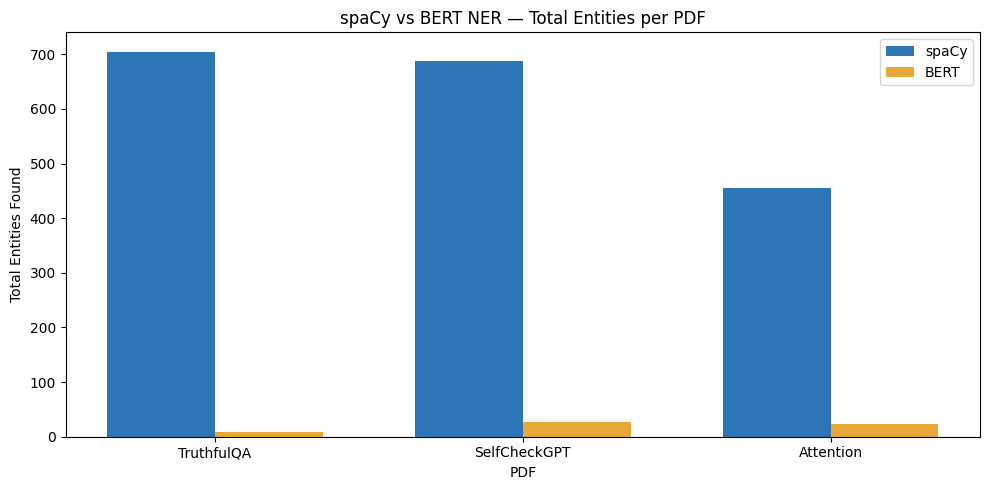

 Chart saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(pdfs.keys())
spacy_total = [sum(len(v) for v in all_entities[n].values()) for n in labels]
bert_total  = [sum(len(v) for v in bert_entities[n].values()) for n in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, spacy_total, width, label='spaCy', color='#2E75B6')
ax.bar(x + width/2, bert_total,  width, label='BERT',  color='#E8A838')

ax.set_xlabel('PDF')
ax.set_ylabel('Total Entities Found')
ax.set_title('spaCy vs BERT NER — Total Entities per PDF')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.savefig("spacy_vs_bert_chart.png")
plt.show()
print(" Chart saved!")

In [ ]:
#Runtime CPU

import time

print("Running spaCy benchmarks on CPU...")
print("="*50)

spacy_times = {}
for name, text in texts.items():
    start = time.time()
    nlp(text[:50000])
    elapsed = time.time() - start
    spacy_times[name] = elapsed
    print(f"{name}: {elapsed:.2f}s (CPU)")

Running spaCy benchmarks on CPU...
TruthfulQA: 6.42s (CPU)
SelfCheckGPT: 6.79s (CPU)
Attention: 7.66s (CPU)


In [ ]:

!pip install spacy pymupdf transformers -q
!python -m spacy download en_core_web_sm -q

!wget -q "https://arxiv.org/pdf/2109.07958" -O truthfulqa.pdf
!wget -q "https://arxiv.org/pdf/2303.08896" -O selfcheckgpt.pdf
!wget -q "https://arxiv.org/pdf/1706.03762" -O attention.pdf

import fitz, re, spacy, time
from transformers import pipeline as hf_pipeline

# Extract text
def extract_and_clean(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    doc.close()
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

pdfs = {
    "TruthfulQA": "truthfulqa.pdf",
    "SelfCheckGPT": "selfcheckgpt.pdf",
    "Attention": "attention.pdf"
}

texts = {}
for name, path in pdfs.items():
    texts[name] = extract_and_clean(path)
    print(f"{name}: {len(texts[name])} chars loaded")

# Load spaCy
nlp = spacy.load("en_core_web_sm")
print("spaCy loaded")

# Load BERT on GPU
bert_ner = hf_pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=0
)
print("BERT NER on GPU loaded")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
TruthfulQA: 92339 chars loaded
SelfCheckGPT: 53546 chars loaded
Attention: 39495 chars loaded
spaCy loaded


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT NER on GPU loaded


In [ ]:
#Runtime CPU

import time

print("Running spaCy benchmarks on CPU...")
print("="*50)

spacy_times = {}
for name, text in texts.items():
    start = time.time()
    nlp(text[:50000])
    elapsed = time.time() - start
    spacy_times[name] = elapsed
    print(f" {name}: {elapsed:.2f}s (CPU)")

Running spaCy benchmarks on CPU...
 TruthfulQA: 3.20s (CPU)
 SelfCheckGPT: 2.47s (CPU)
 Attention: 1.65s (CPU)


In [ ]:
#Runtime GPU

print("\nRunning BERT benchmarks on GPU...")
print("="*50)

bert_gpu_times = {}
for name, text in texts.items():
    start = time.time()
    bert_ner(text[:5000])
    elapsed = time.time() - start
    bert_gpu_times[name] = elapsed
    print(f" {name}: {elapsed:.2f}s (GPU)")


Running BERT benchmarks on GPU...
 TruthfulQA: 0.38s (GPU)
 SelfCheckGPT: 0.07s (GPU)
 Attention: 0.07s (GPU)


In [ ]:
print("\nLoading BERT NER on CPU...")
bert_ner_cpu = hf_pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=-1
)

print("Running BERT benchmarks on CPU...")
print("="*50)

bert_cpu_times = {}
for name, text in texts.items():
    start = time.time()
    bert_ner_cpu(text[:5000])
    elapsed = time.time() - start
    bert_cpu_times[name] = elapsed
    print(f" {name}: {elapsed:.2f}s (CPU)")


Loading BERT NER on CPU...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running BERT benchmarks on CPU...
 TruthfulQA: 1.10s (CPU)
 SelfCheckGPT: 1.03s (CPU)
 Attention: 1.47s (CPU)


In [ ]:
import pandas as pd

rows = []
for name in pdfs.keys():
    rows.append({
        "PDF"           : name,
        "spaCy CPU (s)" : round(spacy_times[name], 2),
        "BERT CPU (s)"  : round(bert_cpu_times[name], 2),
        "BERT GPU (s)"  : round(bert_gpu_times[name], 2),
        "GPU Speedup"   : f"{bert_cpu_times[name] / bert_gpu_times[name]:.1f}x"
    })

df_timing = pd.DataFrame(rows)
print("="*60)
print("         GPU vs CPU NER TIMING TABLE")
print("="*60)
print(df_timing.to_string(index=False))
df_timing.to_csv("ner_timing_benchmark.csv", index=False)
print("\n Saved to ner_timing_benchmark.csv")

         GPU vs CPU NER TIMING TABLE
         PDF  spaCy CPU (s)  BERT CPU (s)  BERT GPU (s) GPU Speedup
  TruthfulQA           3.20          1.10          0.38        2.9x
SelfCheckGPT           2.47          1.03          0.07       14.9x
   Attention           1.65          1.47          0.07       21.9x

 Saved to ner_timing_benchmark.csv
